# Vector Databases Assignment

Hands-on with three vector stores plus a bonus:

1. **FAISS** — local `IndexFlatL2`, top-k search, distance plots, L2 vs cosine.
2. **Chroma** — embedded DB with metadata, dedup behaviour, metadata filtering.
3. **Pinecone** — cloud DB (runs only if `PINECONE_API_KEY` is set) + comparison table.
4. **Bonus — Qdrant** — in-memory, semantic query + metadata filter (no Docker needed).

A shared mini-corpus on *"AI for the environment"* is used throughout.


## Shared corpus & embeddings

In [3]:
pip install faiss

ERROR: Could not find a version that satisfies the requirement faiss (from versions: none)
ERROR: No matching distribution found for faiss


In [1]:
from sentence_transformers import SentenceTransformer
import numpy as np

corpus = [
    "AI4HAB uses artificial intelligence to forecast harmful algal blooms in lakes.",
    "Satellite imagery and computer vision detect illegal deforestation in real time.",
    "Machine learning emulators approximate expensive climate simulations cheaply.",
    "Deep learning improves short-term flood and drought forecasting.",
    "Reinforcement learning reduced cooling energy in large data centres.",
    "Smart grids use AI to balance intermittent wind and solar power.",
    "Precision agriculture cuts fertiliser runoff that pollutes rivers.",
    "Acoustic sensors with audio classification measure biodiversity remotely.",
    "AI monitors shrinking glaciers and the spread of wildfires from space.",
    "Training large AI models has a real carbon footprint that must be measured.",
    "Sensor networks track water temperature to predict algal blooms.",
    "Demand forecasting helps integrate renewable energy into the grid.",
    "Computer vision classifies recyclable materials on sorting lines.",
    "Drones with thermal cameras find heat leaks in buildings.",
    "Federated learning trains models without centralising private sensor data.",
]

metadata = [
    {"title": "AI4HAB", "source": "scientific", "topic": "water"},
    {"title": "Deforestation", "source": "news", "topic": "land"},
    {"title": "Climate emulators", "source": "scientific", "topic": "climate"},
    {"title": "Flood forecasting", "source": "scientific", "topic": "climate"},
    {"title": "Data centre cooling", "source": "blog", "topic": "energy"},
    {"title": "Smart grids", "source": "blog", "topic": "energy"},
    {"title": "Precision agriculture", "source": "news", "topic": "land"},
    {"title": "Bioacoustics", "source": "scientific", "topic": "biodiversity"},
    {"title": "Glacier monitoring", "source": "news", "topic": "climate"},
    {"title": "AI carbon footprint", "source": "scientific", "topic": "energy"},
    {"title": "Bloom sensors", "source": "scientific", "topic": "water"},
    {"title": "Demand forecasting", "source": "blog", "topic": "energy"},
    {"title": "Recycling vision", "source": "news", "topic": "waste"},
    {"title": "Thermal drones", "source": "blog", "topic": "energy"},
    {"title": "Federated learning", "source": "scientific", "topic": "privacy"},
]

embedder = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = embedder.encode(corpus).astype("float32")
print("corpus size:", len(corpus), "| embedding dim:", embeddings.shape[1])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

corpus size: 15 | embedding dim: 384


## Assignment 1  FAISS (local vector search)

Store embeddings in an `IndexFlatL2` index and retrieve the top-k nearest docs.

In [5]:
!pip install faiss-cpu
import faiss

dim = embeddings.shape[1]
index = faiss.IndexFlatL2(dim)          # exact search, squared-L2 distance
index.add(embeddings)
print("vectors in index:", index.ntotal)

query = "How does AI predict algae blooms in water?"
q_emb = embedder.encode([query]).astype("float32")

k = 5
distances, indices = index.search(q_emb, k)

print(f"\nTop-{k} results for: {query!r}\n" + "-" * 60)
for rank, (i, d) in enumerate(zip(indices[0], distances[0]), 1):
    print(f"{rank}. (L2={d:.3f}) {corpus[i]}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 41.6 MB/s eta 0:00:00
vectors in index: 15

Top-5 results for: 'How does AI predict algae blooms in water?'
------------------------------------------------------------
1. (L2=0.488) AI4HAB uses artificial intelligence to forecast harmful algal blooms in lakes.
2. (L2=0.596) Sensor networks track water temperature to predict algal blooms.
3. (L2=1.055) AI monitors shrinking glaciers and the spread of wildfires from space.
4. (L2=1.097) Deep learning improves short-term flood and drought forecasting.
5. (L2=1.376) Machine learning emulators approximate expensive climate simulations cheaply.


### Plot L2 distances of the top-k results

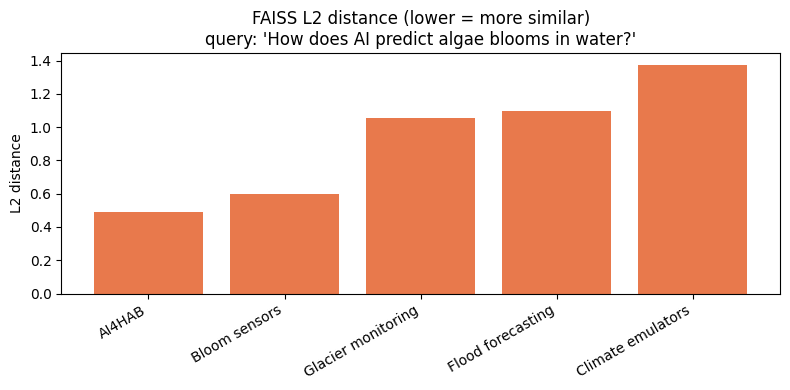

In [6]:
import matplotlib.pyplot as plt

top_docs = [metadata[i]["title"] for i in indices[0]]
plt.figure(figsize=(8, 4))
plt.bar(top_docs, distances[0], color="#E8794C")
plt.title(f"FAISS L2 distance (lower = more similar)\nquery: {query!r}")
plt.ylabel("L2 distance")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### Cosine-similarity heatmap (corpus vs corpus)

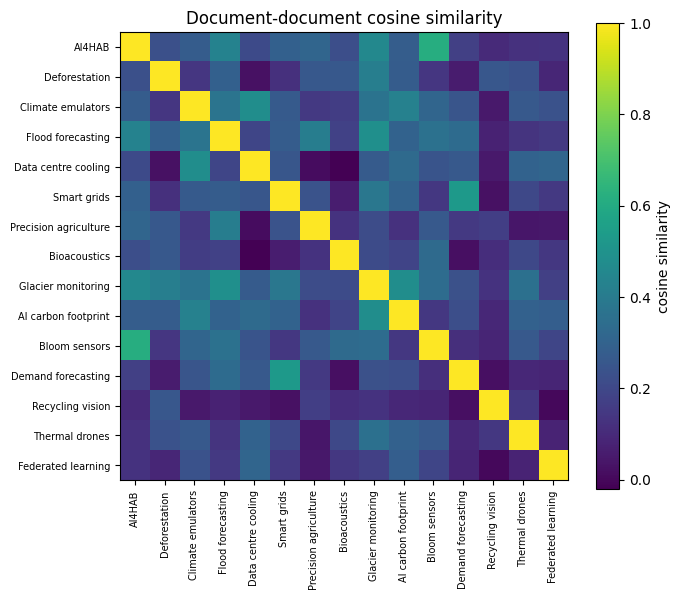

In [7]:
from sklearn.metrics.pairwise import cosine_similarity

sim = cosine_similarity(embeddings)
plt.figure(figsize=(7, 6))
plt.imshow(sim, cmap="viridis")
plt.colorbar(label="cosine similarity")
plt.title("Document-document cosine similarity")
plt.xticks(range(len(corpus)), [m["title"] for m in metadata], rotation=90, fontsize=7)
plt.yticks(range(len(corpus)), [m["title"] for m in metadata], fontsize=7)
plt.tight_layout()
plt.show()

### Normalise embeddings -> L2 search == cosine ranking

In [8]:
# If vectors are L2-normalised, Euclidean distance and cosine similarity give the
# SAME ranking, because ||a-b||^2 = 2 - 2*cos(a,b) for unit vectors.
norm_emb = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)
index_ip = faiss.IndexFlatIP(dim)        # inner product on unit vectors = cosine
index_ip.add(norm_emb)

q_norm = q_emb / np.linalg.norm(q_emb)
sims, idx_ip = index_ip.search(q_norm, k)

print("Cosine (IndexFlatIP, normalised) top-k:")
for i, s in zip(idx_ip[0], sims[0]):
    print(f"  (cos={s:.3f}) {corpus[i]}")

print("\nSame document order as the L2 search above:",
      list(idx_ip[0]) == list(indices[0]))

Cosine (IndexFlatIP, normalised) top-k:
  (cos=0.756) AI4HAB uses artificial intelligence to forecast harmful algal blooms in lakes.
  (cos=0.702) Sensor networks track water temperature to predict algal blooms.
  (cos=0.473) AI monitors shrinking glaciers and the spread of wildfires from space.
  (cos=0.451) Deep learning improves short-term flood and drought forecasting.
  (cos=0.312) Machine learning emulators approximate expensive climate simulations cheaply.

Same document order as the L2 search above: True


### Reflection — L2 vs cosine

- **L2 distance** measures absolute geometric distance and is sensitive to vector
  *magnitude*; **cosine similarity** measures only the *angle* (direction), ignoring
  magnitude.
- After **L2-normalising** the vectors, the two are equivalent for ranking
  (`||a-b||² = 2 − 2·cos`). Sentence-transformer embeddings vary in magnitude, so
  cosine (or normalised L2 / inner-product) is usually the safer choice for semantic
  search.
- **Semantic vs keyword:** the query *"algae blooms"* retrieves the *"harmful algal
  blooms"* doc even though the wording differs — embeddings match meaning, not exact
  tokens, which keyword search (BM25) cannot do.


## Assignment 2 — Chroma (mini knowledge base)

Build a local Chroma collection `ai_water_docs`, add documents with metadata,
query it, and explore dedup + metadata filtering.

In [10]:
!pip install chromadb
import chromadb
from chromadb.utils import embedding_functions

client = chromadb.Client()        # in-memory; use PersistentClient(path=...) to save
try:
    client.delete_collection("ai_water_docs")   # clean re-runs
except Exception:
    pass

ef = embedding_functions.SentenceTransformerEmbeddingFunction(
    model_name="all-MiniLM-L6-v2")
collection = client.create_collection("ai_water_docs", embedding_function=ef)

collection.add(
    documents=corpus,
    metadatas=metadata,
    ids=[f"doc_{i}" for i in range(len(corpus))],
)
print("documents in collection:", collection.count())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 63.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 87.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 46.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.8/71.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.9 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.7/203.7 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 3.4 MB/s eta 0:00:00
  Attempting uninstall: opentelemetry-proto
    Found existing installation: opentelemetry-proto 1.38.0
    Uninstalling openteleme

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

documents in collection: 15


### Query with 3 different questions (top-3 each)

In [11]:
questions = [
    "How does AI detect pollution and protect water?",
    "How is AI used to manage renewable energy?",
    "How does AI help monitor forests and land?",
]

for q in questions:
    res = collection.query(query_texts=[q], n_results=3)
    print(f"Q: {q}\n" + "-" * 60)
    for doc, meta, dist in zip(res["documents"][0], res["metadatas"][0],
                               res["distances"][0]):
        print(f"  [{dist:.3f}] ({meta['title']}) {doc}")
    print()

Q: How does AI detect pollution and protect water?
------------------------------------------------------------
  [0.441] (AI4HAB) AI4HAB uses artificial intelligence to forecast harmful algal blooms in lakes.
  [0.515] (Glacier monitoring) AI monitors shrinking glaciers and the spread of wildfires from space.
  [0.579] (Flood forecasting) Deep learning improves short-term flood and drought forecasting.

Q: How is AI used to manage renewable energy?
------------------------------------------------------------
  [0.288] (Smart grids) Smart grids use AI to balance intermittent wind and solar power.
  [0.447] (Demand forecasting) Demand forecasting helps integrate renewable energy into the grid.
  [0.561] (AI carbon footprint) Training large AI models has a real carbon footprint that must be measured.

Q: How does AI help monitor forests and land?
------------------------------------------------------------
  [0.409] (Glacier monitoring) AI monitors shrinking glaciers and the spread of wi

### Visualize retrieved documents for one query

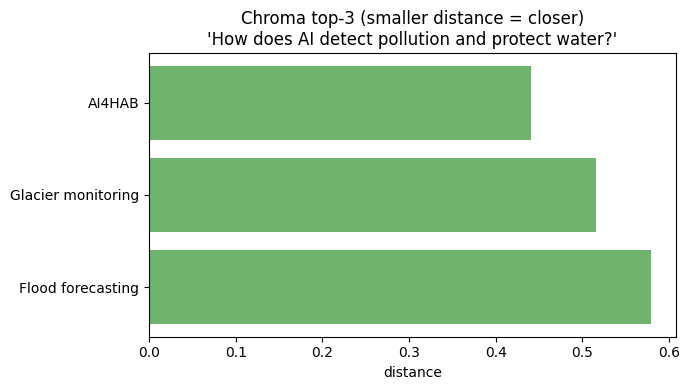

In [12]:
res = collection.query(query_texts=[questions[0]], n_results=3)
titles = [m["title"] for m in res["metadatas"][0]]
dists = res["distances"][0]

plt.figure(figsize=(7, 4))
plt.barh(titles[::-1], dists[::-1], color="#6FB36F")
plt.title(f"Chroma top-3 (smaller distance = closer)\n{questions[0]!r}")
plt.xlabel("distance")
plt.tight_layout()
plt.show()

### Reflection — duplicates & metadata filtering

In [13]:
# (a) Does Chroma deduplicate? IDs are the unique key, NOT the text.
#     Re-adding the SAME id is rejected/upserted (no duplicate);
#     adding the SAME text under a NEW id creates a second copy.
before = collection.count()
try:
    collection.add(documents=[corpus[0]], metadatas=[metadata[0]], ids=["doc_0"])
    print("re-adding id 'doc_0':", collection.count(), "(unchanged -> id is unique)")
except Exception as e:
    print("re-adding id 'doc_0' raised:", type(e).__name__, "-> id must be unique")

collection.add(documents=[corpus[0]], metadatas=[metadata[0]], ids=["doc_0_copy"])
print("adding same text, new id 'doc_0_copy':", collection.count(),
      "(+1 -> text is NOT deduplicated)")
collection.delete(ids=["doc_0_copy"])   # cleanup

# (b) Metadata filtering: only scientific sources
res = collection.query(
    query_texts=["AI for clean water"],
    n_results=3,
    where={"source": "scientific"},
)
print("\nFiltered to source='scientific':")
for doc, meta in zip(res["documents"][0], res["metadatas"][0]):
    print(f"  ({meta['source']}) {doc}")

re-adding id 'doc_0': 15 (unchanged -> id is unique)
adding same text, new id 'doc_0_copy': 16 (+1 -> text is NOT deduplicated)

Filtered to source='scientific':
  (scientific) AI4HAB uses artificial intelligence to forecast harmful algal blooms in lakes.
  (scientific) Deep learning improves short-term flood and drought forecasting.
  (scientific) Training large AI models has a real carbon footprint that must be measured.


## Assignment 3 — Pinecone (cloud vector DB)

This block runs **only if** the environment variable `PINECONE_API_KEY` is set
(a free account is required). Otherwise it is skipped gracefully so the notebook
still runs end-to-end.

In [14]:
import os

PINECONE_API_KEY = os.environ.get("PINECONE_API_KEY")

if not PINECONE_API_KEY:
    print("PINECONE_API_KEY not set -> skipping live Pinecone calls.")
    print("Reference code (what would run) is shown below as a string, not executed.")
    print(r"""
    from pinecone import Pinecone, ServerlessSpec
    pc = Pinecone(api_key=PINECONE_API_KEY)
    if "student-demo" not in [i.name for i in pc.list_indexes()]:
        pc.create_index("student-demo", dimension=384, metric="cosine",
                        spec=ServerlessSpec(cloud="aws", region="us-east-1"))
    index = pc.Index("student-demo")
    index.upsert([(f"doc_{i}", embeddings[i].tolist(), metadata[i])
                  for i in range(len(corpus))])
    res = index.query(vector=q_emb[0].tolist(), top_k=3, include_metadata=True)
    """)
else:
    from pinecone import Pinecone, ServerlessSpec
    pc = Pinecone(api_key=PINECONE_API_KEY)
    if "student-demo" not in [i.name for i in pc.list_indexes()]:
        pc.create_index("student-demo", dimension=dim, metric="cosine",
                        spec=ServerlessSpec(cloud="aws", region="us-east-1"))
    index_pc = pc.Index("student-demo")
    index_pc.upsert(vectors=[(f"doc_{i}", embeddings[i].tolist(), metadata[i])
                             for i in range(len(corpus))])
    res = index_pc.query(vector=q_emb[0].tolist(), top_k=3, include_metadata=True)
    print("Pinecone top-3:")
    for m in res["matches"]:
        print(f"  [{m['score']:.3f}] {m['metadata']['title']}")

PINECONE_API_KEY not set -> skipping live Pinecone calls.
Reference code (what would run) is shown below as a string, not executed.

    from pinecone import Pinecone, ServerlessSpec
    pc = Pinecone(api_key=PINECONE_API_KEY)
    if "student-demo" not in [i.name for i in pc.list_indexes()]:
        pc.create_index("student-demo", dimension=384, metric="cosine",
                        spec=ServerlessSpec(cloud="aws", region="us-east-1"))
    index = pc.Index("student-demo")
    index.upsert([(f"doc_{i}", embeddings[i].tolist(), metadata[i])
                  for i in range(len(corpus))])
    res = index.query(vector=q_emb[0].tolist(), top_k=3, include_metadata=True)
    


### Reflection — FAISS vs Pinecone

| Aspect | FAISS (local) | Pinecone (managed cloud) |
|--------|---------------|--------------------------|
| Setup | `pip install faiss-cpu`, in-process | account + API key + index provisioning |
| Latency | microseconds (in-RAM, no network) | network round-trip (ms), but scales horizontally |
| Persistence | manual (`faiss.write_index`) | managed, durable, replicated |
| Scale | bounded by one machine's RAM | billions of vectors, serverless |
| Metadata filtering | DIY | built-in |
| Cost | free | usage-based |

**Takeaway:** FAISS is ideal for prototyping and single-machine workloads; a managed
DB like Pinecone wins when you need durability, horizontal scale, and filtering
without operating the infrastructure yourself.


## Bonus — Qdrant (in-memory) with metadata filtering

Qdrant runs fully in-memory here (`:memory:`), so no Docker is required. We insert
vectors + payload, then run a semantic query **with** and **without** a metadata
filter.

In [16]:
!pip install qdrant-client
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams, PointStruct, Filter, FieldCondition, MatchValue

qc = QdrantClient(":memory:")
qc.recreate_collection(
    collection_name="research_docs",
    vectors_config=VectorParams(size=dim, distance=Distance.COSINE),
)
qc.upsert(
    collection_name="research_docs",
    points=[PointStruct(id=i, vector=embeddings[i].tolist(), payload=metadata[i])
            for i in range(len(corpus))],
)

q_vec = embedder.encode("AI for clean water and pollution").tolist()

print("Semantic query (no filter):")
for h in qc.query_points("research_docs", query=q_vec, limit=3).points:
    print(f"  [{h.score:.3f}] ({h.payload['source']}) {h.payload['title']}")

print("\nSame query, filtered to source='scientific':")
flt = Filter(must=[FieldCondition(key="source", match=MatchValue(value="scientific"))])
for h in qc.query_points("research_docs", query=q_vec, query_filter=flt, limit=3).points:
    print(f"  [{h.score:.3f}] ({h.payload['source']}) {h.payload['title']}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.1/398.1 kB 10.8 MB/s eta 0:00:00
Semantic query (no filter):
  [0.549] (scientific) AI4HAB
  [0.469] (news) Glacier monitoring
  [0.464] (blog) Smart grids

Same query, filtered to source='scientific':
  [0.549] (scientific) AI4HAB
  [0.433] (scientific) Flood forecasting
  [0.432] (scientific) AI carbon footprint


/tmp/ipykernel_9954/168416263.py:6: DeprecationWarning: `recreate_collection` method is deprecated and will be removed in the future. Use `collection_exists` to check collection existence and `create_collection` instead.
  qc.recreate_collection(


### Bonus notes: Weaviate & Milvus

`Weaviate` (hybrid BM25 + vector) and `Milvus` (large-scale ANN with IVF/HNSW)
require a running server (Docker or cloud), so they are described rather than
executed here:

- **Weaviate hybrid search:** combine `bm25` (keyword) and `nearText` (semantic)
  in one query; hybrid usually beats either alone on mixed factual + semantic
  questions.
- **Milvus ANN:** building an `IVF_FLAT` or `HNSW` index trades a little recall for
  a large speed-up versus the brute-force `IndexFlatL2` used in Assignment 1 —
  essential beyond ~1M vectors.
